In [9]:
# TAREA 2 - ANÁLISIS DE SENTIMIENTO EN RESEÑAS

# Librerías 

import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.metrics.pairwise import cosine_similarity

In [10]:
# Ruta de los archivos de texto

ruta_capitulo_1 = Path(
    r"C:\Users\irwin\Downloads\Capitulo_1.txt"
)

ruta_capitulo_2 = Path(
    r"C:\Users\irwin\Downloads\Capitulo_2.txt"
)

print("Capítulo 1 encontrado:", ruta_capitulo_1.exists())
print("Capítulo 2 encontrado:", ruta_capitulo_2.exists())

Capítulo 1 encontrado: True
Capítulo 2 encontrado: True


In [11]:
# Leer lso archivos de texto

def leer_archivo(ruta):

    codificaciones = [
        "utf-8",
        "utf-8-sig",
        "cp1252",
        "latin-1"
    ]

    for codificacion in codificaciones:

        try:
            return ruta.read_text(
                encoding=codificacion
            )

        except UnicodeDecodeError:
            continue

    raise ValueError(
        f"No fue posible leer el archivo: {ruta}"
    )

texto_capitulo_1 = leer_archivo(
    ruta_capitulo_1
)

texto_capitulo_2 = leer_archivo(
    ruta_capitulo_2
)

print(texto_capitulo_1[:300])
print()
print(texto_capitulo_2[:300])

El niño que vivió
El señor y la señora Dursley, que vivían en el número 4 de Privet Drive, estaban
orgullosos de decir que eran muy normales, afortunadamente. Eran las últimas personas
que se esperaría encontrar relacionadas con algo extraño o misterioso, porque no
estaban para tales tonterías.
El s

El vidrio que se desvaneció 
Habían pasado aproximadamente diez años desde el día en que los Dursley se
despertaron y encontraron a su sobrino en la puerta de entrada, pero Privet Drive no
había cambiado en absoluto. El sol se elevaba en los mismos jardincitos, iluminaba el
número 4 de latón sobre l


In [12]:
# Crear un conjunto de datos 

def separar_parrafos(texto):

    texto = texto.replace("\r\n", "\n")

    parrafos = re.split(
        r"\n\s*\n",
        texto
    )

    parrafos = [
        parrafo.strip()
        for parrafo in parrafos
        if len(parrafo.strip()) >= 40
    ]

    return parrafos

parrafos_capitulo_1 = separar_parrafos(
    texto_capitulo_1
)

parrafos_capitulo_2 = separar_parrafos(
    texto_capitulo_2
)

print(
    "Párrafos del capítulo 1:",
    len(parrafos_capitulo_1)
)

print(
    "Párrafos del capítulo 2:",
    len(parrafos_capitulo_2)
)

df_capitulo_1 = pd.DataFrame({
    "capitulo": "Capítulo 1",
    "texto_original": parrafos_capitulo_1
})

df_capitulo_2 = pd.DataFrame({
    "capitulo": "Capítulo 2",
    "texto_original": parrafos_capitulo_2
})

datos = pd.concat(
    [
        df_capitulo_1,
        df_capitulo_2
    ],
    ignore_index=True
)

datos["id_texto"] = range(
    1,
    len(datos) + 1
)

datos = datos[
    [
        "id_texto",
        "capitulo",
        "texto_original"
    ]
]

display(datos.head())

Párrafos del capítulo 1: 1
Párrafos del capítulo 2: 1


,id_texto,capitulo,texto_original
0,1,Capítulo 1,El niño que vivió\nEl señor y la señora Dursle...
1,2,Capítulo 2,El vidrio que se desvaneció \nHabían pasado ap...


In [13]:
# Limpieza de los datos

def quitar_acentos(texto):

    texto_normalizado = unicodedata.normalize(
        "NFD",
        texto
    )

    return "".join(
        caracter
        for caracter in texto_normalizado
        if unicodedata.category(caracter) != "Mn"
    )

def limpiar_texto(texto):

    texto = str(texto).lower()

    texto = quitar_acentos(texto)

    # Eliminar números
    texto = re.sub(
        r"\d+",
        " ",
        texto
    )

    # Conservar letras y espacios
    texto = re.sub(
        r"[^a-zñ\s]",
        " ",
        texto
    )

    # Eliminar espacios duplicados
    texto = re.sub(
        r"\s+",
        " ",
        texto
    )

    return texto.strip()

datos["texto_limpio"] = datos[
    "texto_original"
].apply(limpiar_texto)

display(
    datos[
        [
            "capitulo",
            "texto_original",
            "texto_limpio"
        ]
    ].head()
)

,capitulo,texto_original,texto_limpio
0,Capítulo 1,El niño que vivió\nEl señor y la señora Dursle...,el nino que vivio el senor y la senora dursley...
1,Capítulo 2,El vidrio que se desvaneció \nHabían pasado ap...,el vidrio que se desvanecio habian pasado apro...


In [14]:
# Stopwords

stopwords_es = {
    "a", "al", "algo", "algunas", "algunos",
    "ante", "antes", "aquel", "aquella",
    "aquellas", "aquello", "aquellos",
    "aqui", "asi", "aunque", "bajo",
    "bien", "cada", "casi", "como",
    "con", "contra", "cual", "cuando",
    "de", "del", "desde", "donde",
    "durante", "e", "el", "ella",
    "ellas", "ellos", "en", "entre",
    "era", "eran", "es", "esa",
    "esas", "ese", "eso", "esos",
    "esta", "estaba", "estaban", "este",
    "esto", "estos", "fue", "fueron",
    "ha", "han", "hasta", "hay",
    "la", "las", "le", "les",
    "lo", "los", "mas", "me",
    "mi", "mientras", "muy", "nos",
    "o", "otra", "otras", "otro",
    "otros", "para", "pero", "poco",
    "por", "porque", "que", "se",
    "ser", "si", "sobre", "son",
    "su", "sus", "tambien", "tan",
    "te", "tenia", "tiene", "todo",
    "todos", "tu", "un", "una",
    "uno", "unos", "usted", "ya", "y",
    "yo"
}

In [15]:
# Vectorización TF-IDF

vectorizador = TfidfVectorizer(
    stop_words=list(stopwords_es),
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

matriz_tfidf = vectorizador.fit_transform(
    datos["texto_limpio"]
)

In [18]:
# Propiedades de los vectores TF-IDF

print(
    "Número de párrafos:",
    matriz_tfidf.shape[0]
)

print(
    "Número de características:",
    matriz_tfidf.shape[1]
)

print(
    "Elementos distintos de cero:",
    matriz_tfidf.nnz
)

total_elementos = (
    matriz_tfidf.shape[0]
    * matriz_tfidf.shape[1]
)

densidad = (
    matriz_tfidf.nnz
    / total_elementos
)

dispersion = 1 - densidad

print(
    "Densidad:",
    round(densidad, 6)
)

print(
    "Dispersión:",
    round(dispersion, 6)
)

Número de párrafos: 2
Número de características: 5505
Elementos distintos de cero: 5505
Densidad: 0.5
Dispersión: 0.5


In [19]:
# Lo más importante por capítulo

terminos = vectorizador.get_feature_names_out()

for capitulo in datos["capitulo"].unique():

    indices = datos[
        datos["capitulo"] == capitulo
    ].index

    promedio_tfidf = np.asarray(
        matriz_tfidf[indices].mean(axis=0)
    ).flatten()

    df_importancia = pd.DataFrame({
        "termino": terminos,
        "tfidf_promedio": promedio_tfidf
    })

    df_importancia = df_importancia.sort_values(
        "tfidf_promedio",
        ascending=False
    ).head(20)

    print("\n" + "=" * 50)
    print(capitulo)
    print("=" * 50)

    display(df_importancia)


Capítulo 1


,termino,tfidf_promedio
1535,dumbledore,0.072869
4123,profesora,0.068874
3013,mcgonagall,0.067072
4125,profesora mcgonagall,0.067072
2056,gato,0.065040
4645,senora dursley,0.062709
2315,hagrid,0.057854
592,capa,0.055403
3304,ni,0.054020
1048,cuenta,0.052505



Capítulo 2


,termino,tfidf_promedio
5028,tia petunia,0.075411
5309,vernon,0.074501
5056,tio vernon,0.072537
4687,serpiente,0.067851
3926,piers,0.066469
5359,vidrio,0.063354
125,alacena,0.061577
765,cocina,0.057417
786,colegio,0.052053
5498,zoologico,0.052053


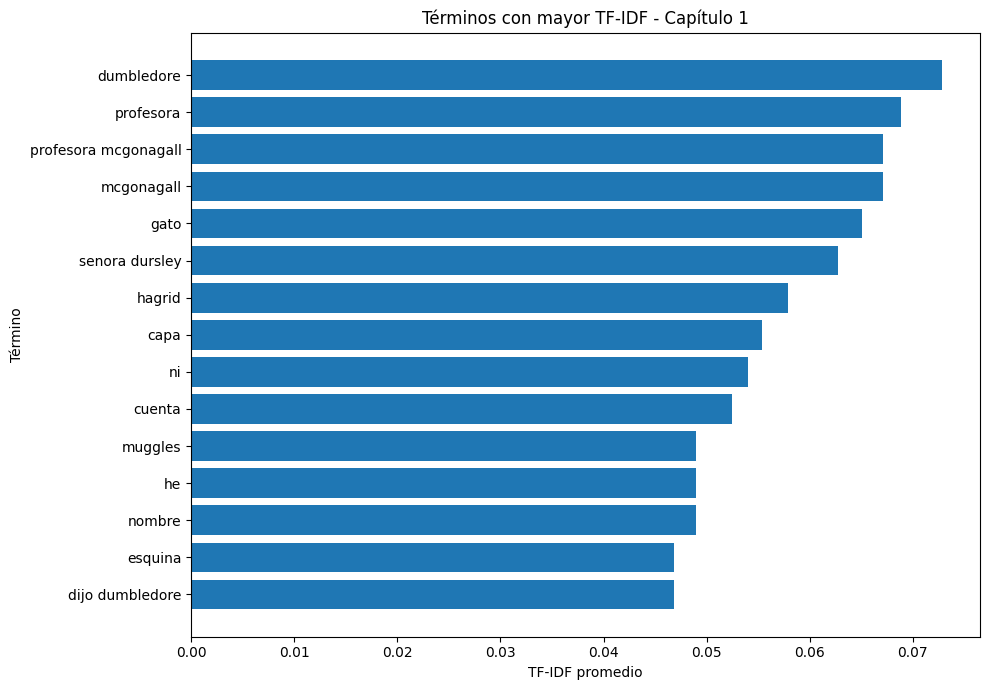

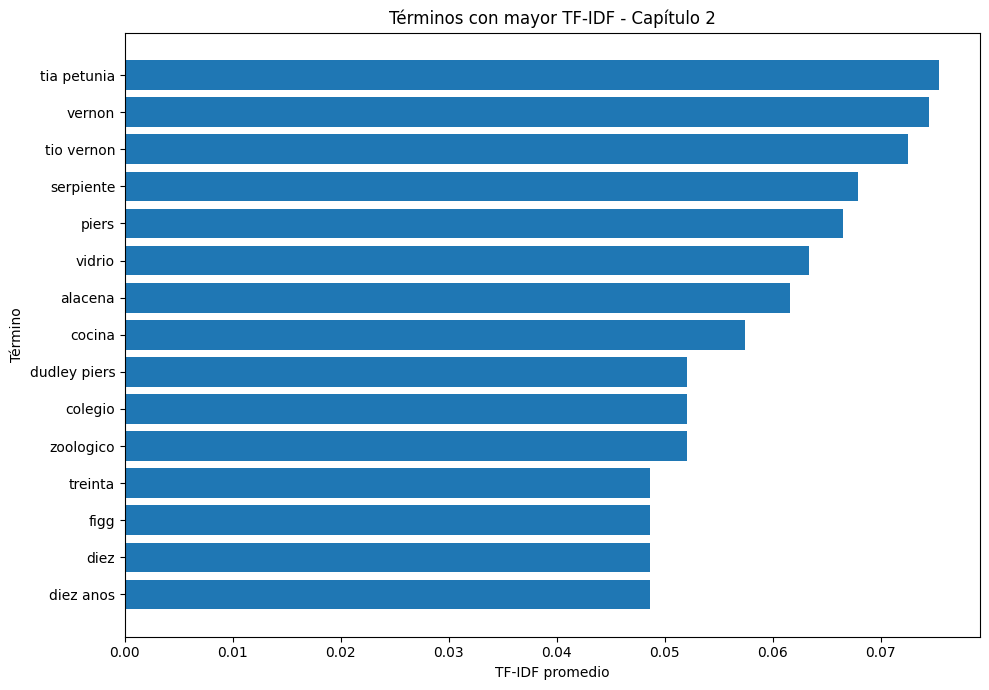

In [20]:
# Gráficas

for capitulo in datos["capitulo"].unique():

    indices = datos[
        datos["capitulo"] == capitulo
    ].index

    promedio_tfidf = np.asarray(
        matriz_tfidf[indices].mean(axis=0)
    ).flatten()

    df_importancia = pd.DataFrame({
        "termino": terminos,
        "tfidf_promedio": promedio_tfidf
    })

    df_importancia = (
        df_importancia
        .sort_values(
            "tfidf_promedio",
            ascending=False
        )
        .head(15)
        .sort_values(
            "tfidf_promedio",
            ascending=True
        )
    )

    plt.figure(figsize=(10, 7))

    plt.barh(
        df_importancia["termino"],
        df_importancia["tfidf_promedio"]
    )

    plt.title(
        f"Términos con mayor TF-IDF - {capitulo}"
    )

    plt.xlabel("TF-IDF promedio")
    plt.ylabel("Término")

    plt.tight_layout()
    plt.show()

In [28]:
# Diccionario de sentimientos

palabras_positivas = {
    "alegre", "alegria", "alegrarse",
    "amor", "amable", "bueno", "buena",
    "bonito", "bonita", "brillante",
    "celebrar", "celebracion", "contento",
    "dulce", "excelente", "feliz",
    "felicidad", "famoso", "favorito",
    "gracias", "gustaba", "gusto",
    "mejor", "perfecto", "sonrisa",
    "sonrio", "suerte", "util",
    "valiente", "maravilloso", "tranquilo",
    "alivio", "aliviado", "admiracion",
    "afortunadamente", "especial"
}

palabras_negativas = {
    "aburrido", "accidente", "amenaza",
    "amenazadora", "angustia", "aullido",
    "castigo", "confuso", "desgraciado",
    "desgracia", "destruida", "dolor",
    "enfadado", "enfadada", "estupido",
    "extraño", "fea", "feo", "furioso",
    "gritar", "grito", "horrible",
    "ira", "llorar", "llanto", "malo",
    "mala", "miedo", "molesto",
    "muerto", "muertos", "nervioso",
    "odio", "oscuro", "peligro",
    "preocupado", "problema", "raro",
    "ridiculo", "romper", "triste",
    "temor", "terrible", "violencia",
    "golpe", "golpear", "lloriqueo",
    "quemadura", "petrificado"
}

In [31]:
# Cálcular sentimientos 

def analizar_sentimiento(texto):

    palabras = texto.split()

    positivos = sum(
        palabra in palabras_positivas
        for palabra in palabras
    )

    negativos = sum(
        palabra in palabras_negativas
        for palabra in palabras
    )

    total = positivos + negativos

    if total == 0:
        puntuacion = 0
    else:
        puntuacion = (
            positivos - negativos
        ) / total

    if puntuacion > 0.15:
        sentimiento = "Positivo"

    elif puntuacion < -0.15:
        sentimiento = "Negativo"

    else:
        sentimiento = "Neutral"

    return pd.Series({
        "palabras_positivas": positivos,
        "palabras_negativas": negativos,
        "puntuacion_sentimiento": puntuacion,
        "sentimiento": sentimiento
    })

resultados_sentimiento = datos[
    "texto_limpio"
].apply(analizar_sentimiento)

datos = pd.concat(
    [
        datos,
        resultados_sentimiento
    ],
    axis=1
)

display(
    datos[
        [
            "capitulo",
            "texto_original",
            "palabras_positivas",
            "palabras_negativas",
            "puntuacion_sentimiento",
            "sentimiento"
        ]
    ].head(10)
)

,capitulo,texto_original,palabras_positivas,palabras_positivas,palabras_negativas,palabras_negativas,puntuacion_sentimiento,puntuacion_sentimiento,sentimiento,sentimiento
0,Capítulo 1,El niño que vivió\nEl señor y la señora Dursle...,37,37,29,29,0.121212,0.121212,Neutral,Neutral
1,Capítulo 2,El vidrio que se desvaneció \nHabían pasado ap...,19,19,30,30,-0.224490,-0.224490,Negativo,Negativo


In [40]:
# Eliminar columnas duplicadas generadas al ejecutar varias veces pd.concat()

datos = datos.loc[:, ~datos.columns.duplicated()].copy()

print(datos.columns.tolist())

['id_texto', 'capitulo', 'texto_original', 'texto_limpio', 'palabras_positivas', 'palabras_negativas', 'puntuacion_sentimiento', 'sentimiento']


In [44]:
# Crear una calificación de sentimiento numérica

def convertir_a_calificacion(puntuacion):

    if puntuacion <= -0.60:
        return 1

    elif puntuacion <= -0.20:
        return 2

    elif puntuacion < 0.20:
        return 3

    elif puntuacion < 0.60:
        return 4

    else:
        return 5

In [43]:
datos["calificacion_estimada"] = datos[
    "puntuacion_sentimiento"
].apply(convertir_a_calificacion)

display(
    datos[
        [
            "capitulo",
            "sentimiento",
            "puntuacion_sentimiento",
            "calificacion_estimada"
        ]
    ].head(15)
)

,capitulo,sentimiento,puntuacion_sentimiento,calificacion_estimada
0,Capítulo 1,Neutral,0.121212,3
1,Capítulo 2,Negativo,-0.224490,2


In [47]:
# Interpretación de los resultados

print("=" * 60)
print("COMPARACIÓN DE SENTIMIENTO Y CALIFICACIÓN ESTIMADA")
print("=" * 60)

for _, fila in datos.iterrows():

    print(
        f"\n{fila['capitulo']}"
    )

    print(
        "Sentimiento:",
        fila["sentimiento"]
    )

    print(
        "Puntuación:",
        round(
            fila["puntuacion_sentimiento"],
            4
        )
    )

    print(
        "Calificación estimada:",
        fila["calificacion_estimada"],
        "de 5"
    )


COMPARACIÓN DE SENTIMIENTO Y CALIFICACIÓN ESTIMADA

Capítulo 1
Sentimiento: Neutral
Puntuación: 0.1212
Calificación estimada: 3 de 5

Capítulo 2
Sentimiento: Negativo
Puntuación: -0.2245
Calificación estimada: 2 de 5


In [ ]:
resumen_sentimiento = (
    datos
    .groupby("capitulo")
    .agg(
        numero_parrafos=(
            "id_texto",
            "count"
        ),
        sentimiento_promedio=(
            "puntuacion_sentimiento",
            "mean"
        ),
        calificacion_promedio=(
            "calificacion_estimada",
            "mean"
        ),
        palabras_positivas=(
            "palabras_positivas",
            "sum"
        ),
        palabras_negativas=(
            "palabras_negativas",
            "sum"
        )
    )
    .reset_index()
)

resumen_sentimiento[
    [
        "sentimiento_promedio",
        "calificacion_promedio"
    ]
] = resumen_sentimiento[
    [
        "sentimiento_promedio",
        "calificacion_promedio"
    ]
].round(3)

display(resumen_sentimiento)

In [ ]:
# Similitud entre capítulos

texto_completo_capitulo_1 = limpiar_texto(
    texto_capitulo_1
)

texto_completo_capitulo_2 = limpiar_texto(
    texto_capitulo_2
)

vectorizador_capitulos = TfidfVectorizer(
    stop_words=list(stopwords_es),
    ngram_range=(1, 2)
)

matriz_capitulos = (
    vectorizador_capitulos.fit_transform(
        [
            texto_completo_capitulo_1,
            texto_completo_capitulo_2
        ]
    )
)

similitud = cosine_similarity(
    matriz_capitulos[0],
    matriz_capitulos[1]
)[0][0]

print(
    "Similitud coseno entre los capítulos:",
    round(similitud, 4)
)

#Cercana a 1: textos muy similares.
#Cercana a 0: textos poco similares.

Similitud coseno entre los capítulos: 0.381
